In [1]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib as mpl
#mpl.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
import seaborn as sns
sns.set_style("white")
sns.set_style("ticks") 
import matlab.engine
eng = matlab.engine.start_matlab()

# Import Freely Moving Data

## Manual Processing and Import

In [ ]:
"""
Load data in as dictionary where keys are frame number (t1,t2,etc.) and key into numpy array with the following columns:
1) Pixel index
2) Normalized (?)
3) X
4) Y
5) X_um
6) Y_um
7) RFP
8) GCaMP
9) RFP-GCaMP_Ratio
10) GCaMP_adj_x
11) GCaMP_adj_y
The remaining columns all have the same value for each row (pixel)
12) Soma_RFP_X position
13) Soma_RFP_Y position
14) Soma_RFP_Mean_Value
15) Soma_GCaMP_X position
16) Soma_GCaMP_Y position
17) Soma_GCaMP_Mean_Value
"""
import glob
numFrames = len(glob.glob("input_MLComp/*.csv"))

data = {}
lacking_data = []
for i in range(numFrames):
    name = "input_MLComp/GCY8Mix_8.2_Tc25_17to24_3__5_MMStack_t"+str(i+1)+".csv"
    temp = np.loadtxt(name, delimiter=',', skiprows=1)
    #print np.shape(temp)
    if len(np.shape(temp)) < 2:
        #print (i+1),"This frame is lacking data"
        lacking_data.append(i+1)
        continue
    else:
        data[str(i+1)] = temp
        


meta_dict = {}
with open("input_MLComp/GCY8Mix_8.2_Tc25_17to24_3__5_MMStack_Pos0_metadata.txt", "r") as metadata:
    for line in metadata:
        pieces = line.split(":")
        if len(pieces) < 2:
            continue
        else:
            if "FrameKey" in pieces[0]:
                key = str(int(pieces[0].split("-")[1])+1)
                meta_dict[key] = {}
            else:
                if eval(pieces[0].strip()) == "MeasuredStageX":
                    meta_dict[key]["StageX"] = float(pieces[1].strip().strip(','))
                elif eval(pieces[0].strip()) == "MeasuredStageY":
                    meta_dict[key]["StageY"] = float(pieces[1].strip().strip(','))
                elif eval(pieces[0].strip()) == "ElapsedTime-ms":
                    meta_dict[key]["ElapsedTime"] = float(pieces[1].strip().strip(','))

In [ ]:
## Fixed 12/2/21 ##

xFOV = []
yFOV = []
frame_list4 = []
for frame in data.keys():
    xFOV.append(meta_dict[frame]["StageX"])
    yFOV.append(meta_dict[frame]["StageY"])
    frame_list4.append(int(frame))
frame_list_sorted4, xFOV_sorted = (list(t) for t in zip(*sorted(zip(frame_list4, xFOV))))
frame_list_sorted4, yFOV_sorted = (list(t) for t in zip(*sorted(zip(frame_list4, yFOV))))

In [ ]:
NeuronXPos = []
NeuronYPos = []
frame_list5 = []
for frame in data.keys():
    NeuronXPos.append(np.nanmean(data[frame][:,11])*1.26)
    NeuronYPos.append(np.nanmean(data[frame][:,12])*1.26)
    frame_list5.append(int(frame))
frame_list_sorted5, NeuronXPos_sorted = (list(t) for t in zip(*sorted(zip(frame_list5, NeuronXPos))))
frame_list_sorted6, NeuronYPos_sorted = (list(t) for t in zip(*sorted(zip(frame_list5, NeuronYPos))))

In [ ]:
xVal = []
deltaX = []
X0 = 15544.999 #this is position at right courner of stage where temp is Xc
for i in range(len(NeuronXPos_sorted)):
    neuron_pos = NeuronXPos_sorted[i]+xFOV_sorted[i]
    xVal.append(neuron_pos)
    deltaX.append(neuron_pos - X0)

Gradient=1.0 # 19 to 21
Origin=17

steepness=((Gradient)*10**-4) #converting gradient steepnes to celcius/um
deltaT=[]
TxTip = []
for i in range(len(deltaX)):
    temp_change = deltaX[i]*steepness
    deltaT.append(temp_change)
    TxTip.append(temp_change+Origin)

smoothed_TxTip = np.array(eng.smoothdata(matlab.single(TxTip), 'gaussian',10))[0].tolist()

yVal = []
for i in range(len(NeuronYPos_sorted)):
    neuron_pos = (NeuronYPos_sorted[i]+yFOV_sorted[i])*(-1)
    yVal.append(neuron_pos)

In [ ]:
Soma_RFP_mean = []
Soma_GCaMP_mean = []
SomaRatio = []
frame_list7 = []
for frame in data.keys():
    temp_RFP = np.nanmean(list(data[frame][:,13].astype(float)))
    temp_GCaMP = np.nanmean(list(data[frame][:,16].astype(float)))
    Soma_RFP_mean.append(temp_RFP)
    Soma_GCaMP_mean.append(temp_GCaMP)
    SomaRatio.append(temp_GCaMP/temp_RFP)
    frame_list7.append(int(frame))
    
frame_list_sorted7, Soma_RFP_mean_sorted, Soma_GCaMP_mean_sorted, Soma_Ratio_sorted = (list(t) for t in zip(*sorted(zip(frame_list7,\
                                                            Soma_RFP_mean, Soma_GCaMP_mean, SomaRatio))))


where_out = eng.isoutlier(matlab.single(Soma_Ratio_sorted), 'mean')
Soma_Ratio_sorted_outlierTrim = np.where(where_out, np.nan, Soma_Ratio_sorted)[0].tolist()
Soma_Ratio_smoothed = np.array(eng.smoothdata(matlab.single(Soma_Ratio_sorted_outlierTrim), 'gaussian',90))[0].tolist()

In [ ]:
Time = []
frame_list8 = []
for frame in meta_dict.keys():
    if int(frame) in lacking_data:
        continue
    else:
        Time.append(float(meta_dict[frame]["ElapsedTime"]))
        frame_list8.append(int(frame))
frame_list_sorted8, Time_sorted = (list(t) for t in zip(*sorted(zip(frame_list8, Time))))

where_out = eng.isoutlier(matlab.single(Soma_GCaMP_mean_sorted), 'mean')
Soma_GCaMP_sorted_outlierTrim = np.where(where_out, np.nan, Soma_GCaMP_mean_sorted)[0].tolist()
Soma_GCaMP_smoothed = np.array(eng.smoothdata(matlab.single(Soma_GCaMP_sorted_outlierTrim), 'gaussian',100))[0].tolist()

where_out = eng.isoutlier(matlab.single(Soma_RFP_mean_sorted), 'mean')
Soma_RFP_sorted_outlierTrim = np.where(where_out, np.nan, Soma_RFP_mean_sorted)[0].tolist()
Soma_RFP_smoothed = np.array(eng.smoothdata(matlab.single(Soma_RFP_sorted_outlierTrim), 'gaussian',100))[0].tolist()


In [ ]:
# Create a dictionary of the processed, sorted lists
# Ensure all lists are the same length (they should be after your sorting steps)
save = True
if save == True:
    export_data = {
        'Frame': frame_list_sorted7,
        'Time_ms': Time_sorted,
        'Temp_TxTip': TxTip,
        'Temp_TxTip_Smoothed': smoothed_TxTip,
        'Neuron_X_um': xVal,
        'Neuron_Y_um': yVal,
        'Soma_Ratio_Raw': Soma_Ratio_sorted,
        'Soma_Ratio_Smoothed': Soma_Ratio_smoothed,
        'GCaMP_Smoothed': Soma_GCaMP_smoothed,
        'RFP_Smoothed': Soma_RFP_smoothed
    }
        
    # Convert to DataFrame
    df_processed = pd.DataFrame(export_data)
    fldrs = "C:/Users/dgmdi/OneDrive - Yale University/Documents/AFD Range of Thermal Perception/Analyses/VR_Compare_Free_vs_Immob_from_3_5_20_steep/"
    # Save to the same folder as your repo for easy access
    save_path = fldrs + "Segment_for_VR_steep_3_4_5_20_Tc25_Processed_Results.csv"
    df_processed.to_csv(save_path, index=False)

    print(f"Successfully saved processed data to {save_path}")

## Direct Import from CSV

In [2]:
import pandas as pd
import os

# --- SETTINGS --- 
source = "csv"
pref = r"VR_Compare_Free_vs_Immob_from_3_5_20_steep/"
file_name = "Segment_for_VR_steep_3_4_5_20_Tc25_Processed_Results.csv"
file_path = os.path.join(pref, file_name)

if source == "csv":
    if os.path.exists(file_path):
        print(f"Loading processed data from: {file_name}")
        df = pd.read_csv(file_path)

        # --- MAPPING BACK TO ORIGINAL VARIABLE NAMES ---
        
        # Cell 2 & 3: Frame and Time
        frame_list_sorted7 = df['Frame'].tolist()
        Time_sorted       = df['Time_ms'].tolist()
        
        # Cell 4: Spatial Coordinates (Microns)
        xVal = df['Neuron_X_um'].tolist()
        yVal = df['Neuron_Y_um'].tolist()
        
        # Cell 4: Temperature Calculations
        TxTip           = df['Temp_TxTip'].tolist()
        smoothed_TxTip  = df['Temp_TxTip_Smoothed'].tolist()
        
        # Cell 5 & 6: Calcium Signaling (Ratio)
        Soma_Ratio_sorted              = df['Soma_Ratio_Raw'].tolist()
        Soma_Ratio_smoothed            = df['Soma_Ratio_Smoothed'].tolist()
        
        # Cell 6: Individual Channels (Smoothed)
        Soma_GCaMP_smoothed = df['GCaMP_Smoothed'].tolist()
        Soma_RFP_smoothed   = df['RFP_Smoothed'].tolist()

        print("Done! All variables restored to manual processing names.")
    else:
        print(f"Error: Could not find {file_path}. Please run the processing cells first.")

Loading processed data from: Segment_for_VR_steep_3_4_5_20_Tc25_Processed_Results.csv
Done! All variables restored to manual processing names.


# Import Immobilized Animal Response To the Thermal Profile and Compare

In [3]:
p = "VR_Compare_Free_vs_Immob_from_3_5_20_steep/"
FastFor_A = pd.read_csv(p + '092120_3055_Hold20_plus_Natur_plus_Ramp_Tc25_2chan_B_1_Results.csv', header=None)
Line_A = pd.read_csv(p + '091720_3055_Hold20_plus_Natur_plus_Ramp_Tc20_2chan_A_1_Results.csv', header=None)
TC25_2_A = pd.read_csv(p + '102120_3055_Hold20_plus_Natur_plus_Ramp_Tc25_B_1_Results.csv', header=None)

FastFor_A_RFP = pd.read_csv(p + '092120_3055_Hold20_plus_Natur_plus_Ramp_Tc25_2chan_B_1_Results_RFP.csv', header=None)
Line_A_RFP = pd.read_csv(p + '091720_3055_Hold20_plus_Natur_plus_Ramp_Tc20_2chan_A_1_Results_RFP.csv', header=None)
TC25_2_A_RFP = pd.read_csv(p + '102120_3055_Hold20_plus_Natur_plus_Ramp_Tc25_B_1_Results_RFP.csv', header=None)


FastFor = np.transpose(np.array(FastFor_A))

FastFor_RFP = np.transpose(np.array(FastFor_A_RFP))

Line = np.transpose(np.array(Line_A))

Line_RFP = np.transpose(np.array(Line_A_RFP))

TC25_2 = np.transpose(np.array(TC25_2_A))

TC25_2_RFP = np.transpose(np.array(TC25_2_A_RFP))

In [4]:
from scipy.stats import sem
from scipy.stats import tstd
from sklearn.preprocessing import minmax_scale

frames_im = range(1,906)

FastFor_Ratio = np.zeros(np.shape(FastFor))
FastFor_scaled = np.zeros(np.shape(FastFor))
for i in range(len(FastFor)):
    for j in range(len(FastFor[i,:])):
        FastFor_Ratio[i,j] = FastFor[i,j]/FastFor_RFP[i,j]
    FastFor_scaled[i,:] = minmax_scale(FastFor_Ratio[i,:], feature_range=(0, 1))
    
FastFor_scaled_mean = []
FastFor_scaled_sem_high = []
FastFor_scaled_sem_low = []
for i in range(len(frames_im)):
    FastFor_scaled_mean.append(np.mean(FastFor_scaled[:,i]))
    FastFor_scaled_sem_high.append(np.mean(FastFor_scaled[:,i])+tstd(FastFor_scaled[:,i]))
    FastFor_scaled_sem_low.append(np.mean(FastFor_scaled[:,i])-tstd(FastFor_scaled[:,i]))

Line_Ratio = np.zeros(np.shape(Line))
Line_scaled = np.zeros(np.shape(Line))
for i in range(len(Line)):
    for j in range(len(Line[i,:])):
        Line_Ratio[i,j] = Line[i,j]/Line_RFP[i,j]
    Line_scaled[i,:] = minmax_scale(Line_Ratio[i,:], feature_range=(0, 1))
    
Line_scaled_mean = []
Line_scaled_sem_high = []
Line_scaled_sem_low = []
for i in range(len(frames_im)):
    Line_scaled_mean.append(np.mean(Line_scaled[:,i]))
    Line_scaled_sem_high.append(np.mean(Line_scaled[:,i])+tstd(Line_scaled[:,i]))
    Line_scaled_sem_low.append(np.mean(Line_scaled[:,i])-tstd(Line_scaled[:,i]))

TC25_2_Ratio = np.zeros(np.shape(TC25_2))
TC25_2_scaled = np.zeros(np.shape(TC25_2))
for i in range(len(Line)):
    for j in range(len(Line[i,:])):
        TC25_2_Ratio[i,j] = TC25_2[i,j]/TC25_2_RFP[i,j]
    TC25_2_scaled[i,:] = minmax_scale(TC25_2_Ratio[i,:], feature_range=(0, 1))
    
TC25_2_scaled_mean = []
TC25_2_scaled_sem_high = []
TC25_2_scaled_sem_low = []
for i in range(len(frames_im)):
    TC25_2_scaled_mean.append(np.mean(TC25_2_scaled[:,i]))
    TC25_2_scaled_sem_high.append(np.mean(TC25_2_scaled[:,i])+tstd(TC25_2_scaled[:,i]))
    TC25_2_scaled_sem_low.append(np.mean(TC25_2_scaled[:,i])-tstd(TC25_2_scaled[:,i]))
    

In [5]:
FastFor_times = []
with open(p + "092120_3055_Hold20_plus_Natur_plus_Ramp_Tc25_2chan_B_1_MMStack_Pos0_metadata.txt", "r") as metadata:
    for line in metadata:
        pieces = line.split(":")
        if len(pieces) < 2:
            continue
        else:
            if eval(pieces[0].strip()) == "Time":
                hour = int(pieces[1].split()[-1])
                #print hour
                minute = int(pieces[2])
                #print minute
                second = int(pieces[3].split()[0])
                #print second
                ms = int(pieces[3].split('-')[1].strip().strip(',').strip('"'))
                #print ms
                converted_time = (hour*60*60*1000)+(minute*60*1000)+(second*1000)+ms
                #print converted_time
                FastFor_times.append(converted_time)
metadata.close()

TC25_2_times = []
with open(p + "102120_3055_Hold20_plus_Natur_plus_Ramp_Tc25_B_1_MMStack_Pos0_metadata.txt", "r") as metadata:
    for line in metadata:
        pieces = line.split(":")
        if len(pieces) < 2:
            continue
        else:
            if eval(pieces[0].strip()) == "Time":
                hour = int(pieces[1].split()[-1])
                #print hour
                minute = int(pieces[2])
                #print minute
                second = int(pieces[3].split()[0])
                #print second
                ms = int(pieces[3].split('-')[1].strip().strip(',').strip('"'))
                #print ms
                converted_time = (hour*60*60*1000)+(minute*60*1000)+(second*1000)+ms
                #print converted_time
                TC25_2_times.append(converted_time)
metadata.close()

Line_times = []
with open(p + "091720_3055_Hold20_plus_Natur_plus_Ramp_Tc20_2chan_A_1_MMStack_Pos0_metadata.txt", "r") as metadata:
    for line in metadata:
        pieces = line.split(":")
        if len(pieces) < 2:
            continue
        else:
            if eval(pieces[0].strip()) == "Time":
                hour = int(pieces[1].split()[-1])
                minute = int(pieces[2])
                second = int(pieces[3].split()[0])
                ms = int(pieces[3].split('-')[1].strip().strip(',').strip('"'))
                converted_time = (hour*60*60*1000)+(minute*60*1000)+(second*1000)+ms
                Line_times.append(converted_time)
metadata.close()

In [12]:
import os

def load_stim_data(file_path):
    temps = []
    times = []
    
    # Extract path-independent time constants
    filename = os.path.basename(file_path)
    parts = filename.split("_")
    hour = int(parts[1][0:2])
    minute = int(parts[1][2:4])
    hour_min_ms = (hour * 3600000) + (minute * 60000)
    
    with open(file_path + ".txt", "r") as stim:
        elapsed_time_check = 0
        elapsed_min = 0
        for line in stim:
            pieces = line.split("\t")
            if not (2 <= len(pieces) <= 4):
                continue
                
            temps.append(float(pieces[0]))
            
            time_parts = pieces[3].split(".")
            sec = int(time_parts[0])
            ms = int(time_parts[1])
            elapsed_time = (elapsed_min * 60000) + (sec * 1000) + ms
            
            if elapsed_time <= elapsed_time_check:
                elapsed_min += 1
                elapsed_time = (elapsed_min * 60000) + (sec * 1000) + ms
            
            times.append(hour_min_ms + elapsed_time)
            elapsed_time_check = elapsed_time
            
    return temps, times

# usage:
FastFor_stim_temps, FastFor_stim_times = load_stim_data(p + "092120_115009_319")
TC25_2_stim_temps, TC25_2_stim_times = load_stim_data(p + "102120_203008_243")
Line_stim_temps, Line_stim_times = load_stim_data(p + "091720_180231_029")

In [13]:
### Alternate Cell Below ###

FastFor_stim_Ca = []
FastFor_stim_up = []
FastFor_stim_low = []
FastFor_adj_times = []
check = 0
for i in range(len(FastFor_stim_times)):
    FastFor_adj_times.append(FastFor_stim_times[i]-FastFor_stim_times[0])
    if FastFor_stim_times[i] > max(FastFor_times):
        FastFor_stim_Ca.append(FastFor_scaled_mean[(len(FastFor_scaled_mean)-1)])
        FastFor_stim_up.append(FastFor_scaled_sem_high[(len(FastFor_scaled_sem_high)-1)])
        FastFor_stim_low.append(FastFor_scaled_sem_low[(len(FastFor_scaled_sem_low)-1)])
        print ('missed end')
    elif FastFor_stim_times[i] < min(FastFor_times):
        FastFor_stim_Ca.append(FastFor_scaled_mean[0])
        FastFor_stim_up.append(FastFor_scaled_sem_high[0])
        FastFor_stim_low.append(FastFor_scaled_sem_low[0])
        print ('missed start')
    else:
        for j in range(check, len(FastFor_times)):
            if FastFor_times[j] <= FastFor_stim_times[i] < FastFor_times[j+1]:
                FastFor_stim_Ca.append(FastFor_scaled_mean[j])
                FastFor_stim_up.append(FastFor_scaled_sem_high[j])
                FastFor_stim_low.append(FastFor_scaled_sem_low[j])
                check = j
                break

Line_stim_Ca = []
Line_stim_up = []
Line_stim_low = []
Line_adj_times = []
check = 0
for i in range(len(Line_stim_times)):
    Line_adj_times.append(Line_stim_times[i]-Line_stim_times[0])
    if Line_stim_times[i] > max(Line_times):
        Line_stim_Ca.append(Line_scaled_mean[(len(Line_scaled_mean)-1)])
        Line_stim_up.append(Line_scaled_sem_high[(len(FastFor_scaled_sem_high)-1)])
        Line_stim_low.append(Line_scaled_sem_low[(len(FastFor_scaled_sem_low)-1)])
        print ('missed end')
    elif Line_stim_times[i] < min(Line_times):
        Line_stim_Ca.append(Line_scaled_mean[0])
        Line_stim_up.append(Line_scaled_sem_high[0])
        Line_stim_low.append(Line_scaled_sem_low[0])
        print ('missed start')
    else:
        for j in range(check, len(Line_times)):
            if Line_times[j] <= Line_stim_times[i] < Line_times[j+1]:
                Line_stim_Ca.append(Line_scaled_mean[j])
                Line_stim_up.append(Line_scaled_sem_high[j])
                Line_stim_low.append(Line_scaled_sem_low[j])
                check = j
                break

In [14]:
TC25_2_stim_Ca = np.zeros((len(TC25_2_scaled),len(TC25_2_stim_times)))
TC25_2_adj_times = []
check = 0
for i in range(len(TC25_2_stim_times)):
    TC25_2_adj_times.append(TC25_2_stim_times[i]-TC25_2_stim_times[0])
    if TC25_2_stim_times[i] > max(TC25_2_times):
        for j in range(len(TC25_2_scaled)):
            TC25_2_stim_Ca[j,i] = TC25_2_scaled[j,(len(TC25_2_scaled[j,:])-1)]
        print ('missed end')
    elif TC25_2_stim_times[i] < min(TC25_2_times):
        for j in range(len(TC25_2_scaled)):
            TC25_2_stim_Ca[j,i] = TC25_2_scaled[j,0]
        print ('missed start')
    else:
        for j in range(check, len(TC25_2_times)):
            if TC25_2_times[j] <= TC25_2_stim_times[i] < TC25_2_times[j+1]:
                for k in range(len(TC25_2_scaled)):
                    TC25_2_stim_Ca[k,i] = TC25_2_scaled[k,j]
                check = j
                break
                
Line_stim_Ca = np.zeros((len(Line_scaled),len(Line_stim_times)))
Line_adj_times = []
check = 0
for i in range(len(Line_stim_times)):
    Line_adj_times.append(Line_stim_times[i]-Line_stim_times[0])
    if Line_stim_times[i] > max(Line_times):
        for j in range(len(Line_scaled)):
            Line_stim_Ca[j,i] = Line_scaled[j,(len(Line_scaled[j,:])-1)]
        print ('missed end')
    elif Line_stim_times[i] < min(Line_times):
        for j in range(len(Line_scaled)):
            Line_stim_Ca[j,i] = Line_scaled[j,0]
        print ('missed start')
    else:
        for j in range(check, len(Line_times)):
            if Line_times[j] <= Line_stim_times[i] < Line_times[j+1]:
                for k in range(len(Line_scaled)):
                    Line_stim_Ca[k,i] = Line_scaled[k,j]
                check = j
                break
                
FastFor_stim_Ca = np.empty((len(FastFor_scaled)+len(TC25_2_scaled),len(FastFor_stim_times)))
FastFor_adj_times = []
check = 0
check2 = 0
for i in range(len(FastFor_stim_times)):
    FastFor_adj_time = FastFor_stim_times[i]-FastFor_stim_times[0]
    FastFor_adj_times.append(FastFor_adj_time)
    if FastFor_stim_times[i] > max(FastFor_times):
        for j in range(len(FastFore_scaled)):
            FastFor_stim_Ca[j,i] = FastFor_scaled[j,(len(FastFor_scaled[j,:])-1)]
        print ('missed end')
    elif FastFor_stim_times[i] < min(FastFor_times):
        for j in range(len(FastFor_scaled)):
            FastFor_stim_Ca[j,i] = FastFor_scaled[j,0]
        print ('missed start')
    else:
        for j in range(check, len(FastFor_times)):
            if FastFor_times[j] <= FastFor_stim_times[i] < FastFor_times[j+1]:
                for k in range(len(FastFor_scaled)):
                    FastFor_stim_Ca[k,i] = FastFor_scaled[k,j]
                check = j
                break
    
    second_check  = 0
    if FastFor_adj_time > (max(TC25_2_times)-TC25_2_times[0]):
        for j in range(len(TC25_2_scaled)):
            FastFor_stim_Ca[j+len(FastFor_scaled),i] = TC25_2_scaled[j,(len(TC25_2_scaled[j,:])-1)]
        print ('missed end')
        second_check += 1
    elif FastFor_adj_time < (TC25_2_times[0]-TC25_2_stim_times[0]):
        for j in range(len(TC25_2_scaled)):
            FastFor_stim_Ca[j+len(FastFor_scaled),i] = TC25_2_scaled[j,0]
        print ('missed start')
        second_check += 1
    else:
        for j in range(check2, len(TC25_2_times)):
            if (TC25_2_times[j]-TC25_2_times[0]) <= FastFor_adj_time < (TC25_2_times[j+1]-TC25_2_times[0]):
                for k in range(len(TC25_2_scaled)):
                    FastFor_stim_Ca[k+len(FastFor_scaled),i] = TC25_2_scaled[k,j]
                check2 = j
                second_check += 1
                break
    if second_check == 0:
        print ('problem')

In [15]:
TC25_mean = []
TC25_sdup = []
TC25_sddown = []
for i in range(len(FastFor_adj_times)):
    TC25_mean.append(np.nanmean(FastFor_stim_Ca[:,i]))
    TC25_sdup.append(np.nanmean(FastFor_stim_Ca[:,i])+tstd(FastFor_stim_Ca[:,i]))
    TC25_sddown.append(np.nanmean(FastFor_stim_Ca[:,i])-tstd(FastFor_stim_Ca[:,i]))
    
TC20_mean = []
TC20_sdup = []
TC20_sddown = []
for i in range(len(Line_adj_times)):
    TC20_mean.append(np.nanmean(Line_stim_Ca[:,i]))
    TC20_sdup.append(np.nanmean(Line_stim_Ca[:,i])+tstd(Line_stim_Ca[:,i]))
    TC20_sddown.append(np.nanmean(Line_stim_Ca[:,i])-tstd(Line_stim_Ca[:,i]))

In [16]:
for i in reversed(range(4000)):
    if FastFor_stim_temps[i]>=20.00:
        trans_index_fast = i
        break
        
for i in reversed(range(4000)):
    if Line_stim_temps[i]>=20.00:
        trans_index_line = i
        break
        
end_index_fast = FastFor_stim_temps[6000:6500].index(min(FastFor_stim_temps[6000:6500]))+6000
end_index_line = Line_stim_temps[6000:6500].index(min(Line_stim_temps[6000:6500]))+6000

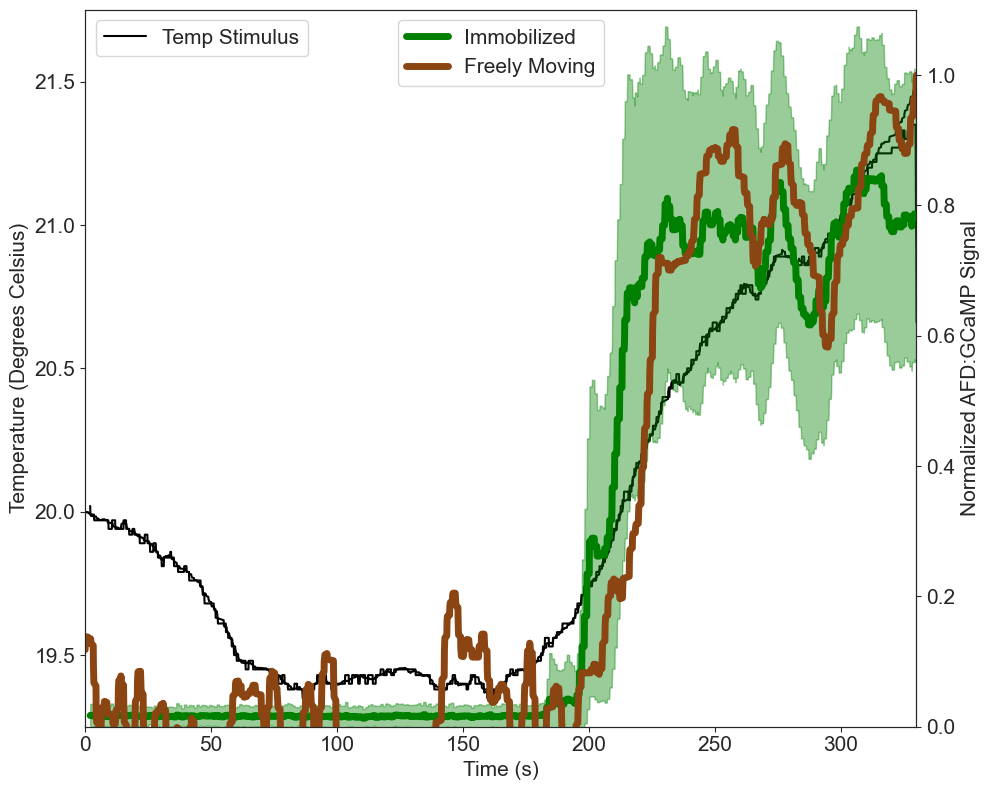

In [17]:
for i in reversed(range(1500)):
    if smoothed_TxTip[i]>=20.00:
        trans_index_free = i
        break

fig, ax1 = plt.subplots(figsize=(10,8))

ax1.plot([(x - Line_adj_times[trans_index_line])/1000 for x in FastFor_adj_times[trans_index_fast:end_index_fast]],FastFor_stim_temps[trans_index_fast:end_index_fast], 'k')

ax1.plot([(x - Time_sorted[trans_index_free])/1000 for x in Time_sorted[trans_index_free:]],smoothed_TxTip[trans_index_free:], 'k')

ax1.set_ylabel('Temperature (Degrees Celsius)', fontsize = 15)
ax1.set_xlabel('Time (s)', fontsize = 15)
ax1.legend(labels=['Temp Stimulus'], fontsize = 15, loc='upper left')

plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)

ax2 = ax1.twinx()

ax2.plot([(x - Line_adj_times[trans_index_line])/1000 for x in FastFor_adj_times[trans_index_fast:end_index_fast]],TC25_mean[trans_index_fast:end_index_fast], 'green', label = "Immobilized", lw=5)
plt.fill_between([(x - Line_adj_times[trans_index_line])/1000 for x in FastFor_adj_times[trans_index_fast:end_index_fast]], TC25_sddown[trans_index_fast:end_index_fast], TC25_sdup[trans_index_fast:end_index_fast], color='green', alpha=0.4)

ax2.plot([(x - Time_sorted[trans_index_free])/1000 for x in Time_sorted[trans_index_free:]],minmax_scale(Soma_Ratio_smoothed[trans_index_free:], feature_range=(-0.2, 1)), 'saddlebrown', label = "Freely Moving", lw=5)

ax2.set_ylabel('Normalized AFD:GCaMP Signal', fontsize = 15)
ax2.legend( fontsize = 15, loc='upper center')

ax1.set_ylim(19.25,21.75)
ax2.set_ylim(0,1.1)
plt.xlim(0,(max(Time_sorted[trans_index_free:])-Time_sorted[trans_index_free])/1000.0)
plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)

fig.tight_layout() 
#savepath="VR_Compare_Free_vs_Immob_from_3_5_20_steep/"
#plt.savefig(savepath + "VR_steep_3_4_5_20_Tc25_Free_vs_Immob.svg", dpi=600)
plt.show()

In [20]:
import numpy as np
from scipy import stats
from sklearn.metrics import mean_squared_error
from scipy.interpolate import interp1d

# 1. Define your shared Time axis (using the shorter of the two datasets)
time_immob = np.array([(x - Line_adj_times[trans_index_line])/1000 for x in FastFor_adj_times[trans_index_fast:end_index_fast]])
data_immob = np.array(TC25_mean[trans_index_fast:end_index_fast])

time_free = np.array([(x - Time_sorted[trans_index_free])/1000 for x in Time_sorted[trans_index_free:]])
data_free = minmax_scale(Soma_Ratio_smoothed[trans_index_free:], feature_range=(-0.2, 1))

# 2. Synchronize: Interpolate 'Free' data onto the 'Immobilized' time points
f_interp = interp1d(time_free, data_free, bounds_error=False, fill_value="extrapolate")
data_free_aligned = f_interp(time_immob)

# 3. Calculate Metrics
# Pearson Correlation (r) and p-value
pearson_r, p_value = stats.pearsonr(data_immob, data_free_aligned)

# Mean Squared Error
mse_value = mean_squared_error(data_immob, data_free_aligned)

# 4. Print Results
print(f"--- Comparison Metrics ---")
print(f"Pearson's r: {pearson_r:.4f}")
print(f"p-value:     {p_value:.4e}")
print(f"MSE:         {mse_value:.4f}")

--- Comparison Metrics ---
Pearson's r: 0.9553
p-value:     0.0000e+00
MSE:         0.0135
